Now working to extract the parameters of defects to help us analyse QDs and make height thresholding estimates

In [49]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.ndimage import median_filter
from skimage import exposure

from scipy.ndimage import binary_fill_holes, gaussian_filter
from skimage.feature import peak_local_max
from skimage.measure import label
from skimage.morphology import white_tophat, disk

z = np.load("data_numpy/2nm_QD_AFMs_AIX6461_along_the_flat_edge_1um_200pN_15gain_2um_zrange.0_00000/channel_00___0_data.npy")
z_nobackground = z - np.mean(z)

Connecting the Jupiter notebooks together

In [48]:
%%capture
%run "./npy-data-QD-DETECTION.ipynb"


**Algorithm for defect detection** 

1. Blur the background so that no small features get detected (gaussian smoothing with a high standard deviation)

2. Only allow features between 20-150 pixels to ramain and apply other thresholding techniques like:
    2.1 Otsu
    2.2 Sauvola
    2.3 Phansaulkar 
    2.4 Others?

3. Measure height at the different positions of the given blobs 

Here the Sauvola thresholding creates the mask, and matplotlib ax.contour sketches the contour.

**1. Detecting QDs within the GaN layer**

In [51]:
# Bright QDs are holes in the dark defect mask.
defect_membership_mask = binary_fill_holes(defect_mask)
defect_membership_labels = label(defect_membership_mask)


# Apply white top-hat filter
tophat_radius = 6 # Choose a radius slightly larger than the typical QD radius.
tophat_map = white_tophat(z_nobackground, footprint=disk(tophat_radius),)
tophat_map = gaussian_filter(tophat_map, sigma=0.7, mode="reflect",)


# Restrict the top-hat response to defects only
tophat_inside_defects = np.where(defect_membership_mask, tophat_map, 0.0,)
inside_values = tophat_inside_defects[defect_membership_mask]
inside_values = inside_values[np.isfinite(inside_values)]
tophat_threshold = np.nanpercentile( inside_values, 85,)


# Detect candidate QDs only inside defects

candidate_peaks_inside = peak_local_max(
    tophat_inside_defects,
    min_distance=3,
    threshold_abs=tophat_threshold,
    exclude_border=False,
    labels=defect_membership_mask.astype(
        np.uint8
    ),
)

print( "Top-hat candidates inside defects:", len(candidate_peaks_inside),)

Top-hat candidates inside defects: 304


**2. Validate each candidate using local dot height**

In [52]:
minimum_dot_height = 6e-10

peak_radius = 1
ring_inner_radius = 3
ring_outer_radius = 7

inside_qd_y = []
inside_qd_x = []
inside_qd_heights = []
inside_qd_defect_ids = []


for candidate_y, candidate_x in candidate_peaks_inside:

    defect_id = int(defect_membership_labels[candidate_y, candidate_x,])

    if defect_id == 0:
        continue

    y0 = max(0, candidate_y - ring_outer_radius,)
    y1 = min(z_nobackground.shape[0], candidate_y + ring_outer_radius + 1,)

    x0 = max(0, candidate_x - ring_outer_radius,)
    x1 = min(z_nobackground.shape[1], candidate_x + ring_outer_radius + 1,)

    local_height = z_nobackground[y0:y1, x0:x1,]
    local_labels = defect_membership_labels[y0:y1, x0:x1,]

    yy, xx = np.ogrid[y0:y1, x0:x1,]

    rr2 = ((yy - candidate_y) ** 2 + (xx - candidate_x) ** 2)

    peak_mask = (rr2 <= peak_radius**2)
    ring_mask = ((rr2 >= ring_inner_radius**2) & (rr2 <= ring_outer_radius**2))

    same_defect_ring = ( ring_mask & (local_labels == defect_id))

    peak_values = local_height[peak_mask]
    background_values = local_height[same_defect_ring]
    peak_values = peak_values[np.isfinite(peak_values)]

    background_values = background_values[np.isfinite(background_values)]

    if (peak_values.size == 0 or background_values.size < 8):
        continue

    local_peak = np.nanmax(peak_values)
    local_background = np.nanmedian(background_values)
    local_dot_height = (local_peak - local_background)

    if local_dot_height >= minimum_dot_height:
        inside_qd_y.append(candidate_y)
        inside_qd_x.append(candidate_x)
        inside_qd_heights.append(local_dot_height)
        inside_qd_defect_ids.append(defect_id)


inside_qd_y = np.asarray(inside_qd_y, dtype=int,)
inside_qd_x = np.asarray(inside_qd_x, dtype=int,)
inside_qd_heights = np.asarray(inside_qd_heights, dtype=float,)
inside_qd_defect_ids = np.asarray(inside_qd_defect_ids, dtype=int,)

print("Accepted QDs inside defects:", len(inside_qd_y),)

if len(inside_qd_heights) > 0:
    print("Median height:", np.median(inside_qd_heights) * 1e9, "nm",)

Accepted QDs inside defects: 181
Median height: 1.5265999999999893 nm


**3. Plotting Accepted dots on the GaN layer on the original AFM image**

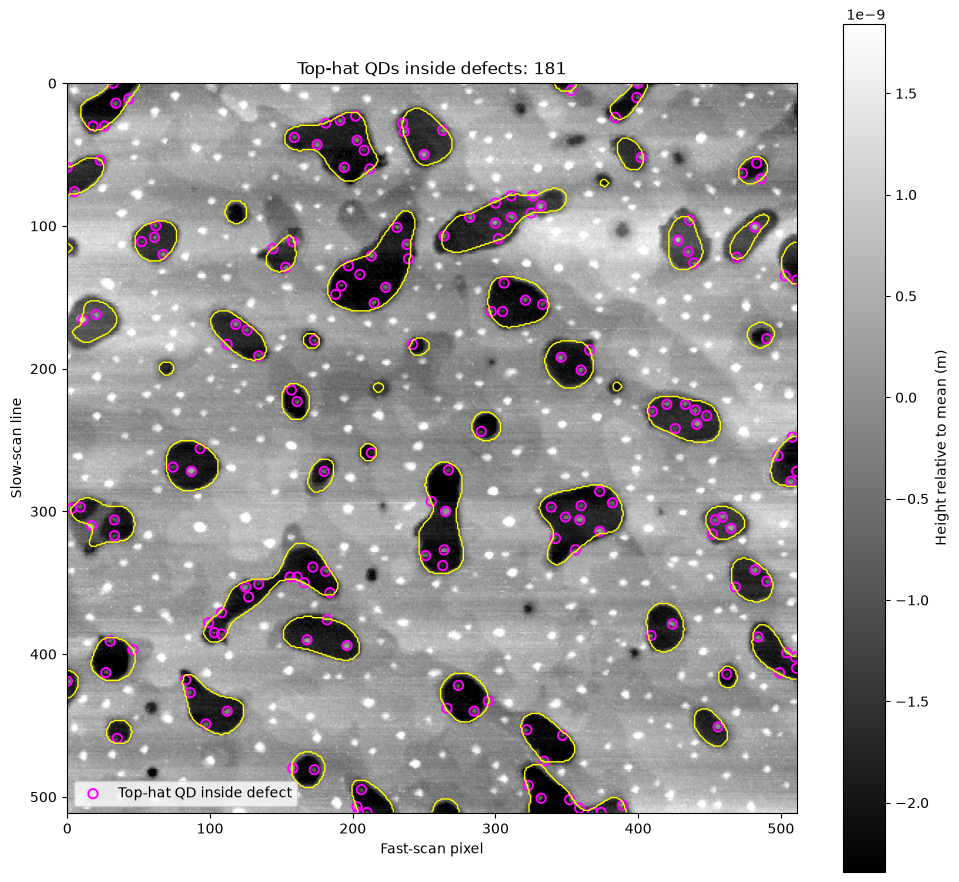

In [54]:
fig, ax = plt.subplots(figsize=(10, 9))

image_display = ax.imshow(
    z_nobackground,
    cmap="gray",
    vmin=np.nanpercentile( z_nobackground, 1,),
    vmax=np.nanpercentile( z_nobackground, 99, ),
)

ax.contour(defect_mask, levels=[0.5], colors="yellow", linewidths=1.0,) #level 0.5 is the standard contour value used for evaluating the contour along a binary mask 

ax.scatter(
    inside_qd_x,
    inside_qd_y,
    s=45,
    facecolors="none",
    edgecolors="magenta",
    linewidths=1.4,
    label="Top-hat QD inside defect",
)

ax.set_title(
    f"Top-hat QDs inside defects: "
    f"{len(inside_qd_y)}"
)

ax.set_xlabel("Fast-scan pixel")
ax.set_ylabel("Slow-scan line")

fig.colorbar( image_display, ax=ax, label="Height relative to mean (m)",)

ax.legend()
plt.tight_layout()
plt.show()

**4. Detecting QDs outside of the GaN layer, so these QDs will be on the InGaN layer:**

In [55]:
# Detect top-hat QDs outside defects

outside_mask = (~defect_membership_mask & np.isfinite(z_nobackground))

tophat_outside_defects = np.where(outside_mask, tophat_map, 0.0,)

outside_values = tophat_outside_defects[outside_mask]
outside_values = outside_values[np.isfinite(outside_values)]

outside_tophat_threshold = np.nanpercentile(outside_values, 85,)

candidate_peaks_outside = peak_local_max(
    tophat_outside_defects,
    min_distance=3,
    threshold_abs=outside_tophat_threshold,
    exclude_border=False,
    labels=outside_mask.astype(np.uint8),
)

print("Top-hat candidates outside defects:", len(candidate_peaks_outside),)

Top-hat candidates outside defects: 1666


**5.  Validate outside candidates by local height**

In [59]:
minimum_dot_height = 6e-10

peak_radius = 2
ring_inner_radius = 3
ring_outer_radius = 7

outside_qd_y = []
outside_qd_x = []
outside_qd_heights = []


for candidate_y, candidate_x in candidate_peaks_outside:

    # Candidate must remain outside defects
    if defect_membership_mask[candidate_y, candidate_x,]:
        continue

    y0 = max(0, candidate_y - ring_outer_radius,)
    y1 = min(z_nobackground.shape[0], candidate_y + ring_outer_radius + 1,)

    x0 = max(0, candidate_x - ring_outer_radius,)
    x1 = min(z_nobackground.shape[1], candidate_x + ring_outer_radius + 1,)

    local_height = z_nobackground[y0:y1, x0:x1,]
    local_membership = defect_membership_mask[y0:y1, x0:x1,]

    yy, xx = np.ogrid[y0:y1, x0:x1,]
    rr2 = ((yy - candidate_y) ** 2 + (xx - candidate_x) ** 2)

    peak_mask = (rr2 <= peak_radius**2)

    ring_mask = ((rr2 >= ring_inner_radius**2) & (rr2 <= ring_outer_radius**2))

    # Use only non-defect pixels for the outside background.
    outside_background_ring = (ring_mask & (~local_membership))

    peak_values = local_height[peak_mask]
    background_values = local_height[outside_background_ring]
    peak_values = peak_values[np.isfinite(peak_values)]
    background_values = background_values[np.isfinite(background_values)]

    if (peak_values.size == 0 or background_values.size < 8):
        continue

    local_peak = np.nanmax(peak_values)
    local_background = np.nanmedian(background_values)
    local_dot_height = (local_peak - local_background)

    if local_dot_height >= minimum_dot_height:
        outside_qd_y.append(candidate_y)
        outside_qd_x.append(candidate_x)
        outside_qd_heights.append(local_dot_height)


outside_qd_y = np.asarray(outside_qd_y, dtype=int,)
outside_qd_x = np.asarray(outside_qd_x, dtype=int,)

outside_qd_heights = np.asarray(outside_qd_heights, dtype=float,)

print("Accepted QDs outside defects:", len(outside_qd_y),)

if len(outside_qd_heights) > 0:
    print("Median outside QD height:", np.median(outside_qd_heights) * 1e9,"nm",)

Accepted QDs outside defects: 691
Median outside QD height: 1.5094539999999963 nm


**6. Plot inside QDs in pink and outside QDs in orange**

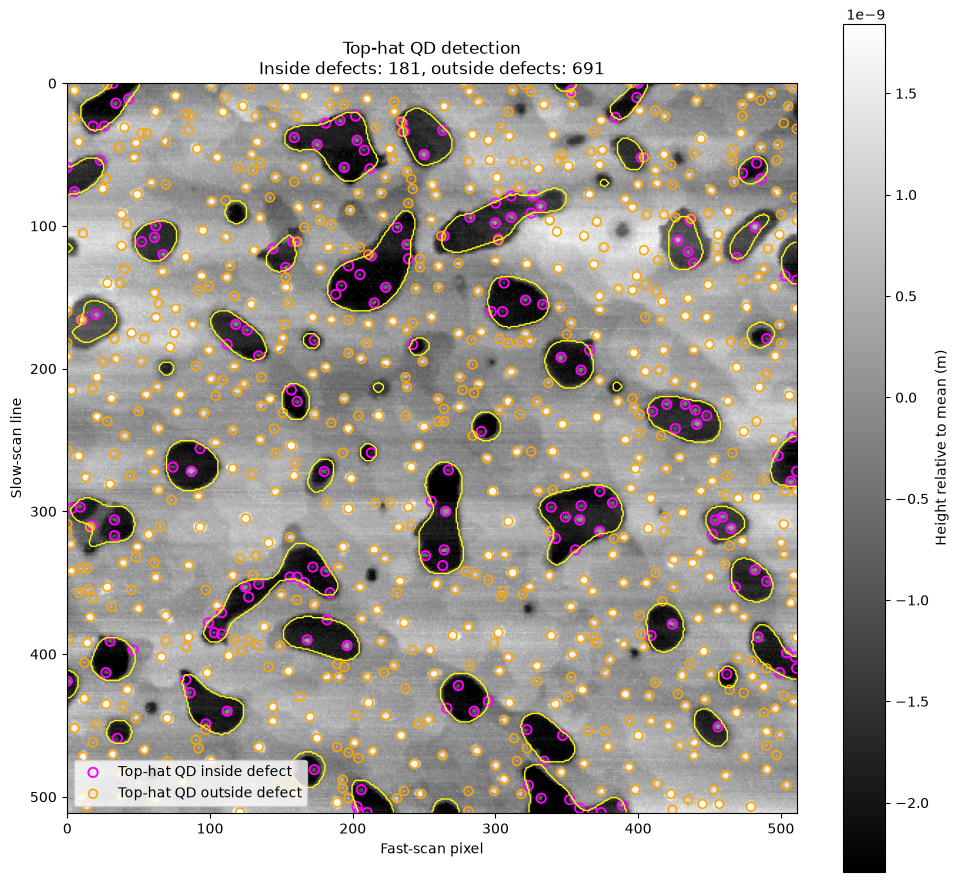

In [60]:
fig, ax = plt.subplots(
    figsize=(10, 9)
)

image_display = ax.imshow(
    z_nobackground,
    cmap="gray",
    vmin=np.nanpercentile( z_nobackground, 1,),
    vmax=np.nanpercentile( z_nobackground, 99, ),
)

ax.contour(defect_mask, levels=[0.5], colors="yellow", linewidths=1.0,)

# Inside-defect QDs
ax.scatter(
    inside_qd_x,
    inside_qd_y,
    s=45,
    facecolors="none",
    edgecolors="magenta",
    linewidths=1.4,
    label="Top-hat QD inside defect",
)

# Outside-defect QDs
ax.scatter(
    outside_qd_x,
    outside_qd_y,
    s=40,
    facecolors="none",
    edgecolors="orange",
    linewidths=1.2,
    label="Top-hat QD outside defect",
)

ax.set_title(
    f"Top-hat QD detection\n"
    f"Inside defects: {len(inside_qd_y)}, "
    f"outside defects: {len(outside_qd_y)}"
)

ax.set_xlabel("Fast-scan pixel")
ax.set_ylabel("Slow-scan line")
fig.colorbar( image_display, ax=ax, label="Height relative to mean (m)",)
ax.legend()
plt.tight_layout()
plt.show()

Now, since we have 2 classes, we can compare if dots on GaN layer and dots on the InGaN layer are morphologically different. 

**To do this, lets compare:**
* local height above surrounding surface
* full width at half maximum in x and y
* equivalent diameter
* area above a relative-height threshold
* aspect ratio
* eccentricity
* circularity
* top-hat response strength
* local defect depth for inside-defect dots

In [61]:
import numpy as np
import pandas as pd

from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects


geometry_radius = 8

# Segment each dot at this fraction of its local peak height.
relative_contour_fraction = 0.50
minimum_segment_area = 3

# Combine both QD classes
all_qd_y = np.concatenate(
    [
        inside_qd_y,
        outside_qd_y,
    ]
)

all_qd_x = np.concatenate(
    [
        inside_qd_x,
        outside_qd_x,
    ]
)

all_qd_class = np.concatenate(
    [
        np.full(
            len(inside_qd_y),
            "inside_defect",
            dtype=object,
        ),
        np.full(
            len(outside_qd_y),
            "outside_defect",
            dtype=object,
        ),
    ]
)


# Measure each QD

qd_features = []


for qd_id, (
    centre_y,
    centre_x,
    qd_class,
) in enumerate(
    zip(
        all_qd_y,
        all_qd_x,
        all_qd_class,
    ),
    start=1,
):

    y0 = max(
        0,
        centre_y - geometry_radius,
    )
    y1 = min(
        z_nobackground.shape[0],
        centre_y + geometry_radius + 1,
    )

    x0 = max(
        0,
        centre_x - geometry_radius,
    )
    x1 = min(
        z_nobackground.shape[1],
        centre_x + geometry_radius + 1,
    )

    patch = z_nobackground[
        y0:y1,
        x0:x1,
    ]

    yy, xx = np.ogrid[
        y0:y1,
        x0:x1,
    ]

    rr2 = (
        (yy - centre_y) ** 2
        + (xx - centre_x) ** 2
    )

    background_ring = (
        (rr2 >= 5**2)
        & (rr2 <= geometry_radius**2)
    )

    background_values = patch[
        background_ring
    ]

    background_values = background_values[
        np.isfinite(background_values)
    ]

    if background_values.size < 10:
        continue

    local_background = np.nanmedian(
        background_values
    )

    local_patch = (
        patch - local_background
    )

    local_peak = np.nanmax(
        local_patch
    )

    if (
        not np.isfinite(local_peak)
        or local_peak <= 0
    ):
        continue

    contour_level = (
        relative_contour_fraction
        * local_peak
    )

    dot_binary = (
        local_patch >= contour_level
    )

    dot_binary = remove_small_objects(
        dot_binary,
        min_size=minimum_segment_area,
    )

    dot_labels = label(
        dot_binary
    )

    local_centre_y = (
        centre_y - y0
    )

    local_centre_x = (
        centre_x - x0
    )

    dot_label_at_centre = dot_labels[
        local_centre_y,
        local_centre_x,
    ]

    # If the exact centre is not segmented, use the nearest
    # segmented component to the detected peak.
    if dot_label_at_centre == 0:

        regions = regionprops(
            dot_labels
        )

        if len(regions) == 0:
            continue

        distances = []

        for region in regions:

            region_y, region_x = (
                region.centroid
            )

            distance = np.hypot(
                region_y - local_centre_y,
                region_x - local_centre_x,
            )

            distances.append(
                distance
            )

        selected_region = regions[
            np.argmin(distances)
        ]

    else:

        selected_region = regionprops(
            dot_labels
        )[
            dot_label_at_centre - 1
        ]


    area_pixels = selected_region.area

    equivalent_diameter = (
        selected_region.equivalent_diameter_area
    )

    major_axis = (
        selected_region.axis_major_length
    )

    minor_axis = (
        selected_region.axis_minor_length
    )

    eccentricity = (
        selected_region.eccentricity
    )

    perimeter = (
        selected_region.perimeter
    )

    if perimeter > 0:

        circularity = (
            4
            * np.pi
            * area_pixels
            / perimeter**2
        )

    else:

        circularity = np.nan


    if minor_axis > 0:

        aspect_ratio = (
            major_axis
            / minor_axis
        )

    else:

        aspect_ratio = np.nan


    # --------------------------------------------
    # Estimate FWHM directly from horizontal profile
    # --------------------------------------------

    horizontal_profile = local_patch[
        local_centre_y,
        :
    ]

    vertical_profile = local_patch[
        :,
        local_centre_x,
    ]

    half_height = (
        0.5 * local_peak
    )

    horizontal_above = np.where(
        horizontal_profile >= half_height
    )[0]

    vertical_above = np.where(
        vertical_profile >= half_height
    )[0]

    if horizontal_above.size > 0:

        fwhm_x_pixels = (
            horizontal_above[-1]
            - horizontal_above[0]
            + 1
        )

    else:

        fwhm_x_pixels = np.nan


    if vertical_above.size > 0:

        fwhm_y_pixels = (
            vertical_above[-1]
            - vertical_above[0]
            + 1
        )

    else:

        fwhm_y_pixels = np.nan


    qd_features.append(
        {
            "qd_id": qd_id,
            "class": qd_class,
            "centre_y": centre_y,
            "centre_x": centre_x,
            "height_m": local_peak,
            "height_nm": local_peak * 1e9,
            "area_pixels": area_pixels,
            "equivalent_diameter_pixels":
                equivalent_diameter,
            "major_axis_pixels":
                major_axis,
            "minor_axis_pixels":
                minor_axis,
            "aspect_ratio":
                aspect_ratio,
            "eccentricity":
                eccentricity,
            "perimeter_pixels":
                perimeter,
            "circularity":
                circularity,
            "fwhm_x_pixels":
                fwhm_x_pixels,
            "fwhm_y_pixels":
                fwhm_y_pixels,
        }
    )


qd_feature_table = pd.DataFrame(
    qd_features
)

print(
    qd_feature_table.head()
)

print(
    "\nNumber of measured QDs by class:"
)

print(
    qd_feature_table[
        "class"
    ].value_counts()
)

/var/folders/mh/m6vpz3p153zc20j8vy1vf3780000gn/T/ipykernel_60926/3993541561.py:139: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  dot_binary = remove_small_objects(


   qd_id          class  centre_y  centre_x      height_m  height_nm  \
0      1  inside_defect       272        87  2.503482e-09   2.503482   
1      2  inside_defect       394       196  2.295410e-09   2.295410   
2      3  inside_defect       166        11  2.500661e-09   2.500661   
3      4  inside_defect        50       250  2.324020e-09   2.324020   
4      5  inside_defect       300       265  2.160300e-09   2.160300   

   area_pixels  equivalent_diameter_pixels  major_axis_pixels  \
0         24.0                    5.527906           5.887841   
1         21.0                    5.170883           5.529214   
2         22.0                    5.292567           5.803252   
3         16.0                    4.513517           4.799359   
4         25.0                    5.641896           6.013281   

   minor_axis_pixels  aspect_ratio  eccentricity  perimeter_pixels  \
0           5.225472      1.126758      0.460803         15.899495   
1           4.942678      1.118668  

Comparing the QD parameters

In [62]:
summary_table = (
    qd_feature_table
    .groupby("class")
    [
        [
            "height_nm",
            "area_pixels",
            "equivalent_diameter_pixels",
            "major_axis_pixels",
            "minor_axis_pixels",
            "aspect_ratio",
            "eccentricity",
            "circularity",
            "fwhm_x_pixels",
            "fwhm_y_pixels",
        ]
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
        ]
    )
)

print(
    summary_table
)

               height_nm                               area_pixels             \
                   count      mean    median       std       count       mean   
class                                                                           
inside_defect        180  2.148251  2.175123  0.567558         180  46.161111   
outside_defect       599  1.792219  1.831743  0.450573         599  14.803005   

                                 equivalent_diameter_pixels            ...  \
               median        std                      count      mean  ...   
class                                                                  ...   
inside_defect    43.0  35.853233                        180  6.971519  ...   
outside_defect   14.0   9.511369                        599  4.181234  ...   

               circularity           fwhm_x_pixels                             \
                    median       std         count      mean median       std   
class                                    

Height Distributions

In [35]:
import numpy as np
import pandas as pd


# ============================================================
# 1. Combine accepted dots from both classes
# ============================================================

all_qd_y = np.concatenate(
    [
        inside_qd_y,
        outside_qd_y,
    ]
)

all_qd_x = np.concatenate(
    [
        inside_qd_x,
        outside_qd_x,
    ]
)

all_qd_heights = np.concatenate(
    [
        inside_qd_heights,
        outside_qd_heights,
    ]
)

all_qd_class = np.concatenate(
    [
        np.full(
            len(inside_qd_y),
            "inside_defect",
            dtype=object,
        ),
        np.full(
            len(outside_qd_y),
            "outside_defect",
            dtype=object,
        ),
    ]
)


# ============================================================
# 2. Rebuild feature records from scratch
# ============================================================

qd_features = []

for qd_id, (
    centre_y,
    centre_x,
    accepted_height,
    qd_class,
) in enumerate(
    zip(
        all_qd_y,
        all_qd_x,
        all_qd_heights,
        all_qd_class,
    ),
    start=1,
):

    qd_features.append(
        {
            "qd_id": qd_id,
            "class": qd_class,
            "centre_y": int(centre_y),
            "centre_x": int(centre_x),

            # Validated height from the detection stage
            "height_m": float(accepted_height),
            "height_nm": float(
                accepted_height * 1e9
            ),
            "height_A": float(
                accepted_height * 1e10
            ),
        }
    )


# Create the DataFrame only after the loop
qd_feature_table = pd.DataFrame(
    qd_features
)


# ============================================================
# 3. Validate the height threshold
# ============================================================

print(
    "Number of QDs:",
    len(qd_feature_table),
)

if len(inside_qd_heights) > 0:
    print(
        "Minimum inside height:",
        np.min(inside_qd_heights) * 1e10,
        "Å",
    )
else:
    print("No inside-defect QDs detected.")


if len(outside_qd_heights) > 0:
    print(
        "Minimum outside height:",
        np.min(outside_qd_heights) * 1e10,
        "Å",
    )
else:
    print("No outside-defect QDs detected.")


print(
    "Inside below 6 Å:",
    np.sum(
        inside_qd_heights < 6e-10
    ),
)

print(
    "Outside below 6 Å:",
    np.sum(
        outside_qd_heights < 6e-10
    ),
)

print(
    "Feature-table dots below 6 Å:",
    np.sum(
        qd_feature_table["height_A"] < 6
    ),
)


print(
    qd_feature_table[
        [
            "class",
            "height_nm",
            "height_A",
        ]
    ].groupby("class").describe()
)

Number of QDs: 890
Minimum inside height: 6.112350000000034 Å
Minimum outside height: 6.006590000000004 Å
Inside below 6 Å: 0
Outside below 6 Å: 0
Feature-table dots below 6 Å: 0
               height_nm                                                    \
                   count      mean       std       min       25%       50%   
class                                                                        
inside_defect      205.0  1.491336  0.469061  0.611235  1.146995  1.468545   
outside_defect     685.0  1.411654  0.576884  0.600659  0.787951  1.507130   

                                   height_A                                \
                     75%       max    count       mean       std      min   
class                                                                       
inside_defect   1.832855  2.540872    205.0  14.913363  4.690615  6.11235   
outside_defect  1.869221  3.188852    685.0  14.116540  5.768841  6.00659   

                                            

Height Distributions

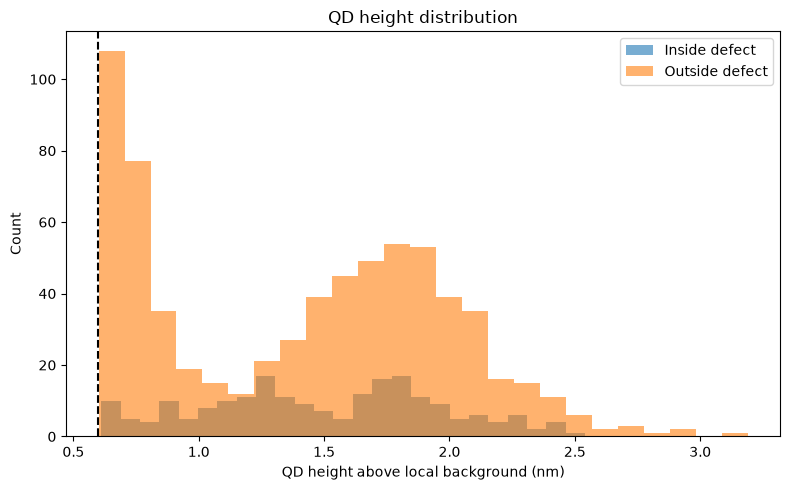

In [36]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.hist(
    qd_feature_table.loc[
        qd_feature_table["class"]
        == "inside_defect",
        "height_nm",
    ],
    bins=25,
    alpha=0.6,
    label="Inside defect",
)

ax.hist(
    qd_feature_table.loc[
        qd_feature_table["class"]
        == "outside_defect",
        "height_nm",
    ],
    bins=25,
    alpha=0.6,
    label="Outside defect",
)

ax.set_xlabel(
    "QD height above local background (nm)"
)

ax.set_ylabel(
    "Count"
)

ax.set_title(
    "QD height distribution"
)

ax.legend()

ax.axvline(
    0.6,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="6 Å threshold",
)

plt.tight_layout()
plt.show()

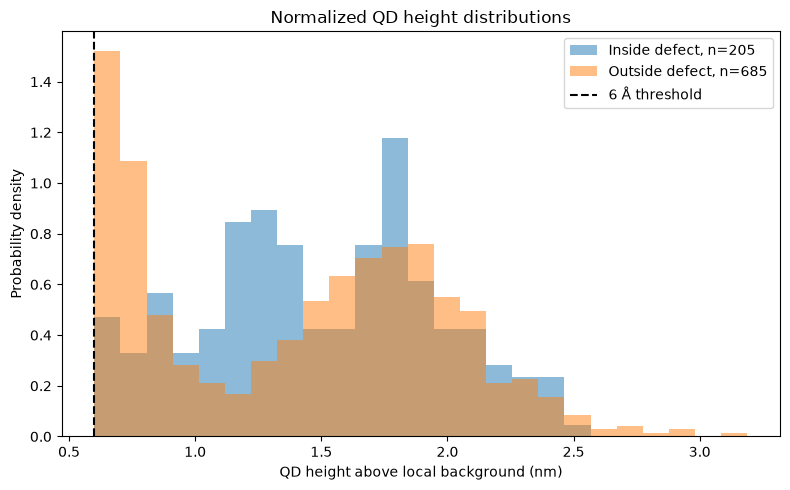

Minimum height in table: 0.6006590000000004 nm
Dots below 0.6 nm: 0


In [37]:
inside_heights_nm = qd_feature_table.loc[
    qd_feature_table["class"] == "inside_defect",
    "height_nm",
]

outside_heights_nm = qd_feature_table.loc[
    qd_feature_table["class"] == "outside_defect",
    "height_nm",
]


fig, ax = plt.subplots(
    figsize=(8, 5)
)

common_bins = np.linspace(
    0.6,
    max(
        inside_heights_nm.max(),
        outside_heights_nm.max(),
    ),
    26,
)

ax.hist(
    inside_heights_nm,
    bins=common_bins,
    density=True,
    alpha=0.5,
    label=f"Inside defect, n={len(inside_heights_nm)}",
)

ax.hist(
    outside_heights_nm,
    bins=common_bins,
    density=True,
    alpha=0.5,
    label=f"Outside defect, n={len(outside_heights_nm)}",
)

ax.axvline(
    0.6,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="6 Å threshold",
)

ax.set_xlabel(
    "QD height above local background (nm)"
)

ax.set_ylabel(
    "Probability density"
)

ax.set_title(
    "Normalized QD height distributions"
)

ax.legend()

plt.tight_layout()
plt.show()

print(
    "Minimum height in table:",
    qd_feature_table["height_nm"].min(),
    "nm",
)

print(
    "Dots below 0.6 nm:",
    np.sum(
        qd_feature_table["height_nm"] < 0.6
    ),
)

Width distribution

In [39]:
import numpy as np
import pandas as pd

from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects


geometry_radius = 8
relative_contour_fraction = 0.5
minimum_segment_area = 3


all_qd_y = np.concatenate(
    [
        inside_qd_y,
        outside_qd_y,
    ]
)

all_qd_x = np.concatenate(
    [
        inside_qd_x,
        outside_qd_x,
    ]
)

all_qd_heights = np.concatenate(
    [
        inside_qd_heights,
        outside_qd_heights,
    ]
)

all_qd_class = np.concatenate(
    [
        np.full(
            len(inside_qd_y),
            "inside_defect",
            dtype=object,
        ),
        np.full(
            len(outside_qd_y),
            "outside_defect",
            dtype=object,
        ),
    ]
)


qd_features = []


for qd_id, (
    centre_y,
    centre_x,
    accepted_height,
    qd_class,
) in enumerate(
    zip(
        all_qd_y,
        all_qd_x,
        all_qd_heights,
        all_qd_class,
    ),
    start=1,
):

    centre_y = int(centre_y)
    centre_x = int(centre_x)

    y0 = max(
        0,
        centre_y - geometry_radius,
    )
    y1 = min(
        z_nobackground.shape[0],
        centre_y + geometry_radius + 1,
    )

    x0 = max(
        0,
        centre_x - geometry_radius,
    )
    x1 = min(
        z_nobackground.shape[1],
        centre_x + geometry_radius + 1,
    )

    patch = z_nobackground[
        y0:y1,
        x0:x1,
    ]

    yy, xx = np.ogrid[
        y0:y1,
        x0:x1,
    ]

    rr2 = (
        (yy - centre_y) ** 2
        + (xx - centre_x) ** 2
    )

    background_ring = (
        (rr2 >= 5**2)
        & (rr2 <= geometry_radius**2)
    )

    background_values = patch[
        background_ring
    ]

    background_values = background_values[
        np.isfinite(background_values)
    ]

    if background_values.size < 10:
        continue

    local_background = np.nanmedian(
        background_values
    )

    local_patch = (
        patch - local_background
    )

    local_peak_for_geometry = np.nanmax(
        local_patch
    )

    if (
        not np.isfinite(local_peak_for_geometry)
        or local_peak_for_geometry <= 0
    ):
        continue

    contour_level = (
        relative_contour_fraction
        * local_peak_for_geometry
    )

    dot_binary = (
        local_patch >= contour_level
    )

    dot_binary = remove_small_objects(
        dot_binary,
        min_size=minimum_segment_area,
    )

    dot_labels = label(
        dot_binary
    )

    local_centre_y = centre_y - y0
    local_centre_x = centre_x - x0

    centre_label = dot_labels[
        local_centre_y,
        local_centre_x,
    ]

    regions = regionprops(
        dot_labels
    )

    if len(regions) == 0:
        continue

    if centre_label > 0:

        selected_region = next(
            region
            for region in regions
            if region.label == centre_label
        )

    else:

        distances = []

        for region in regions:

            region_y, region_x = (
                region.centroid
            )

            distances.append(
                np.hypot(
                    region_y - local_centre_y,
                    region_x - local_centre_x,
                )
            )

        selected_region = regions[
            np.argmin(distances)
        ]


    area_pixels = float(
        selected_region.area
    )

    equivalent_diameter = float(
        selected_region.equivalent_diameter_area
    )

    major_axis = float(
        selected_region.axis_major_length
    )

    minor_axis = float(
        selected_region.axis_minor_length
    )

    eccentricity = float(
        selected_region.eccentricity
    )

    perimeter = float(
        selected_region.perimeter
    )

    if minor_axis > 0:
        aspect_ratio = (
            major_axis / minor_axis
        )
    else:
        aspect_ratio = np.nan

    if perimeter > 0:
        circularity = (
            4
            * np.pi
            * area_pixels
            / perimeter**2
        )
    else:
        circularity = np.nan


    horizontal_profile = local_patch[
        local_centre_y,
        :
    ]

    vertical_profile = local_patch[
        :,
        local_centre_x,
    ]

    half_height = (
        0.5 * local_peak_for_geometry
    )

    horizontal_indices = np.where(
        horizontal_profile >= half_height
    )[0]

    vertical_indices = np.where(
        vertical_profile >= half_height
    )[0]

    if horizontal_indices.size > 0:
        fwhm_x_pixels = (
            horizontal_indices[-1]
            - horizontal_indices[0]
            + 1
        )
    else:
        fwhm_x_pixels = np.nan

    if vertical_indices.size > 0:
        fwhm_y_pixels = (
            vertical_indices[-1]
            - vertical_indices[0]
            + 1
        )
    else:
        fwhm_y_pixels = np.nan


    qd_features.append(
        {
            "qd_id": qd_id,
            "class": qd_class,
            "centre_y": centre_y,
            "centre_x": centre_x,

            # Preserve the accepted height from detection
            "height_m": float(
                accepted_height
            ),
            "height_nm": float(
                accepted_height * 1e9
            ),
            "height_A": float(
                accepted_height * 1e10
            ),

            "area_pixels": area_pixels,
            "equivalent_diameter_pixels":
                equivalent_diameter,
            "major_axis_pixels":
                major_axis,
            "minor_axis_pixels":
                minor_axis,
            "aspect_ratio":
                aspect_ratio,
            "eccentricity":
                eccentricity,
            "perimeter_pixels":
                perimeter,
            "circularity":
                circularity,
            "fwhm_x_pixels":
                fwhm_x_pixels,
            "fwhm_y_pixels":
                fwhm_y_pixels,
        }
    )


qd_feature_table = pd.DataFrame(
    qd_features
)

print(qd_feature_table.columns.tolist())

print(
    "Measured QDs:",
    len(qd_feature_table),
)

print(
    "Dots below 6 Å:",
    np.sum(
        qd_feature_table["height_A"] < 6
    ),
)

/var/folders/mh/m6vpz3p153zc20j8vy1vf3780000gn/T/ipykernel_60926/1725465195.py:147: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  dot_binary = remove_small_objects(


['qd_id', 'class', 'centre_y', 'centre_x', 'height_m', 'height_nm', 'height_A', 'area_pixels', 'equivalent_diameter_pixels', 'major_axis_pixels', 'minor_axis_pixels', 'aspect_ratio', 'eccentricity', 'perimeter_pixels', 'circularity', 'fwhm_x_pixels', 'fwhm_y_pixels']
Measured QDs: 794
Dots below 6 Å: 0


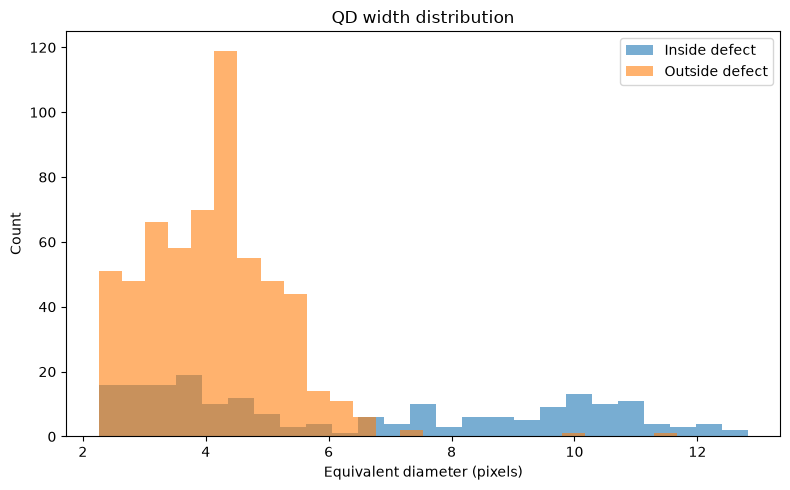

In [40]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.hist(
    qd_feature_table.loc[
        qd_feature_table["class"]
        == "inside_defect",
        "equivalent_diameter_pixels",
    ],
    bins=25,
    alpha=0.6,
    label="Inside defect",
)

ax.hist(
    qd_feature_table.loc[
        qd_feature_table["class"]
        == "outside_defect",
        "equivalent_diameter_pixels",
    ],
    bins=25,
    alpha=0.6,
    label="Outside defect",
)

ax.set_xlabel(
    "Equivalent diameter (pixels)"
)

ax.set_ylabel(
    "Count"
)

ax.set_title(
    "QD width distribution"
)

ax.legend()

plt.tight_layout()
plt.show()

Height vs. Width 

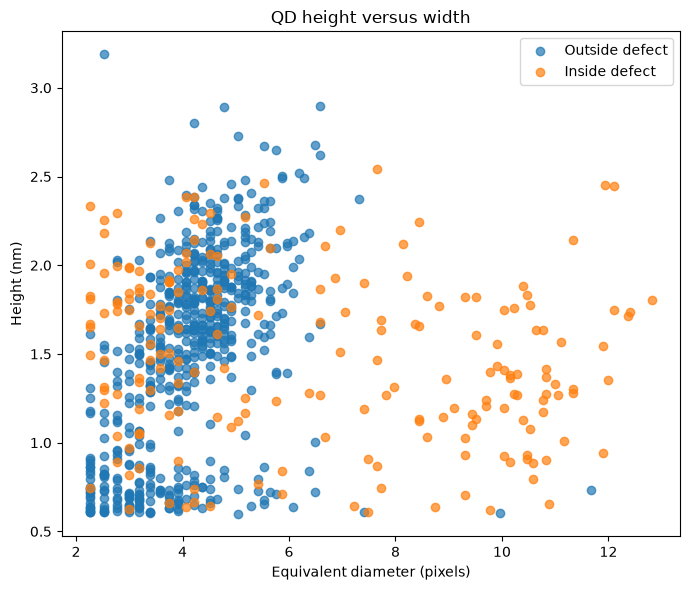

In [41]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

inside_rows = (
    qd_feature_table["class"]
    == "inside_defect"
)

outside_rows = (
    qd_feature_table["class"]
    == "outside_defect"
)

ax.scatter(
    qd_feature_table.loc[
        outside_rows,
        "equivalent_diameter_pixels",
    ],
    qd_feature_table.loc[
        outside_rows,
        "height_nm",
    ],
    alpha=0.7,
    label="Outside defect",
)

ax.scatter(
    qd_feature_table.loc[
        inside_rows,
        "equivalent_diameter_pixels",
    ],
    qd_feature_table.loc[
        inside_rows,
        "height_nm",
    ],
    alpha=0.7,
    label="Inside defect",
)

ax.set_xlabel(
    "Equivalent diameter (pixels)"
)

ax.set_ylabel(
    "Height (nm)"
)

ax.set_title(
    "QD height versus width"
)

ax.legend()

plt.tight_layout()
plt.show()